# Lineare Regression: Kleinste Quadrate von Grund auf

**Notebook 01 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Dieses Notebook entwickelt die lineare Regression vollständig aus den mathematischen
Grundlagen und implementiert sie ausschließlich mit `NumPy`. Aus dem
Kleinste-Quadrate-Kriterium werden die Normalengleichungen hergeleitet, in einer
numerisch stabilen Variante (QR-Zerlegung) gelöst und einem iterativen
Gradientenverfahren gegenübergestellt. Als Datengrundlage dient ein simulierter
Datensatz mit vollständig bekanntem datengenerierendem Prozess (DGP); dadurch lassen
sich die Punktschätzungen $\hat\beta$ direkt mit den wahren Parametern $\beta$
vergleichen — eine Möglichkeit, die empirische Datensätze grundsätzlich nicht bieten.
Ergänzend werden Standardfehler, $t$-Statistiken und Konfidenzintervalle berechnet,
eine Residuendiagnostik durchgeführt und die Eigenimplementierung gegen
`scikit-learn` validiert.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. das Kleinste-Quadrate-Kriterium als Optimierungsproblem formulieren und die
   Normalengleichungen herleiten,
2. begründen, warum die explizite Inversion von $X^\top X$ numerisch zu vermeiden ist,
3. die geschlossene Lösung und das Gradientenverfahren hinsichtlich Aufwand und
   Konvergenz gegeneinander abwägen,
4. Standardfehler und Konfidenzintervalle der Koeffizienten interpretieren,
5. mittels Residuendiagnostik prüfen, ob die Modellannahmen verletzt sind.

## Inhalt

1. [Problemstellung und Notation](#1)
2. [Theoretischer Rahmen](#2)
3. [Rechenumgebung und Reproduzierbarkeit](#3)
4. [Datengrundlage: simulierter DGP](#4)
5. [Implementierung](#5)
6. [Empirische Analyse](#6)
7. [Diskussion und Grenzen](#7)
8. [Übungsaufgaben](#8)
9. [Literatur](#9)

<a id="1"></a>
## 1 Problemstellung und Notation

Gegeben sei eine Stichprobe $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ mit
Merkmalsvektoren $\mathbf{x}_i \in \mathbb{R}^{p}$ und stetiger Zielgröße
$y_i \in \mathbb{R}$. Gesucht ist eine affine Abbildung

$$
f(\mathbf{x}) = \beta_0 + \sum_{j=1}^{p} \beta_j x_j = \tilde{\mathbf{x}}^\top \boldsymbol\beta,
\qquad \tilde{\mathbf{x}} = (1, x_1, \dots, x_p)^\top ,
$$

die den erwarteten quadratischen Vorhersagefehler minimiert. In Matrixschreibweise mit
der Designmatrix $X \in \mathbb{R}^{n \times (p+1)}$, deren erste Spalte konstant $1$
ist, lautet das Modell

$$
\mathbf{y} = X\boldsymbol\beta + \boldsymbol\varepsilon .
$$

| Symbol | Bedeutung |
|---|---|
| $n$ | Stichprobenumfang |
| $p$ | Anzahl der Merkmale (ohne Achsenabschnitt) |
| $X$ | Designmatrix, $n \times (p+1)$ |
| $\boldsymbol\beta$ | wahrer Parametervektor |
| $\hat{\boldsymbol\beta}$ | Kleinste-Quadrate-Schätzer |
| $\boldsymbol\varepsilon$ | Störterm mit $\mathbb{E}[\boldsymbol\varepsilon]=\mathbf{0}$ |
| $\sigma^2$ | Varianz des Störterms |

<a id="2"></a>
## 2 Theoretischer Rahmen

### 2.1 Modellannahmen

Die klassischen Annahmen des linearen Modells (Gauß-Markov-Annahmen, vgl.
Hastie et al., 2009, Kap. 3) sind

* **(A1) Linearität:** $\mathbb{E}[y \mid \mathbf{x}] = \tilde{\mathbf{x}}^\top \boldsymbol\beta$.
* **(A2) Exogenität:** $\mathbb{E}[\varepsilon_i \mid X] = 0$.
* **(A3) Homoskedastizität und Unkorreliertheit:** $\operatorname{Cov}(\boldsymbol\varepsilon \mid X) = \sigma^2 I_n$.
* **(A4) Vollrang:** $\operatorname{rank}(X) = p+1$, insbesondere $n > p+1$.

Unter (A1)–(A4) ist $\hat{\boldsymbol\beta}$ nach dem Gauß-Markov-Theorem der
varianzminimale unter allen linearen unverzerrten Schätzern (BLUE). Für Tests und
Konfidenzintervalle in kleinen Stichproben wird zusätzlich
**(A5) Normalverteilung** $\boldsymbol\varepsilon \sim \mathcal{N}(\mathbf{0}, \sigma^2 I_n)$
benötigt.

### 2.2 Kleinste-Quadrate-Kriterium

Der Schätzer minimiert die Residuenquadratsumme (*residual sum of squares*)

$$
\operatorname{RSS}(\boldsymbol\beta)
  = \sum_{i=1}^{n}\bigl(y_i - \tilde{\mathbf{x}}_i^\top\boldsymbol\beta\bigr)^2
  = \lVert \mathbf{y} - X\boldsymbol\beta \rVert_2^2 .
$$

### 2.3 Herleitung der Normalengleichungen

Ausmultiplizieren liefert

$$
\operatorname{RSS}(\boldsymbol\beta)
  = \mathbf{y}^\top\mathbf{y} - 2\boldsymbol\beta^\top X^\top \mathbf{y}
    + \boldsymbol\beta^\top X^\top X \boldsymbol\beta .
$$

Der Gradient bezüglich $\boldsymbol\beta$ ist

$$
\nabla_{\boldsymbol\beta}\operatorname{RSS}
  = -2X^\top\mathbf{y} + 2X^\top X\boldsymbol\beta
  \;\overset{!}{=}\; \mathbf{0}
\quad\Longleftrightarrow\quad
\underbrace{X^\top X\,\hat{\boldsymbol\beta} = X^\top \mathbf{y}}_{\text{Normalengleichungen}} .
$$

Die Hesse-Matrix $\nabla^2_{\boldsymbol\beta}\operatorname{RSS} = 2X^\top X$ ist unter
(A4) positiv definit, der stationäre Punkt somit das globale Minimum. Bei vollem Rang
folgt formal

$$
\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top \mathbf{y}.
$$

> **Numerischer Hinweis.** Diese Formel ist eine *mathematische*, keine *algorithmische*
> Vorschrift. Die Kondition von $X^\top X$ ist das Quadrat der Kondition von $X$,
> $\kappa(X^\top X) = \kappa(X)^2$. Statt zu invertieren, löst man das
> Ausgleichsproblem $\min_\beta \lVert \mathbf{y}-X\boldsymbol\beta\rVert_2$ direkt über
> eine QR- oder SVD-Zerlegung (Golub & Van Loan, 2013, Kap. 5); genau das tut
> `numpy.linalg.lstsq`. Abschnitt 6.5 quantifiziert diesen Unterschied.

### 2.4 Der Spezialfall der einfachen Regression

Für $p = 1$ reduzieren sich die Normalengleichungen auf die aus der Statistik-Grundvorlesung
bekannte Form

$$
\hat\beta_1 = \frac{\sum_{i}(x_i-\bar{x})(y_i-\bar{y})}{\sum_i (x_i-\bar{x})^2}
          = \frac{\widehat{\operatorname{Cov}}(x,y)}{\widehat{\operatorname{Var}}(x)},
\qquad
\hat\beta_0 = \bar{y} - \hat\beta_1\bar{x}.
$$

### 2.5 Iterative Alternative: Gradientenverfahren

Für $n \gg 0$ oder $p \gg 0$ ist die geschlossene Lösung mit
$\mathcal{O}(np^2 + p^3)$ zu teuer. Das Gradientenverfahren nutzt stattdessen die
Iteration

$$
\boldsymbol\beta^{(t+1)}
  = \boldsymbol\beta^{(t)} - \eta \cdot \frac{2}{n} X^\top\bigl(X\boldsymbol\beta^{(t)} - \mathbf{y}\bigr),
$$

mit Lernrate $\eta > 0$ und Kosten $\mathcal{O}(np)$ pro Schritt. Da
$\operatorname{RSS}$ konvex ist, konvergiert das Verfahren für
$\eta < 1/\lambda_{\max}\!\left(\tfrac{1}{n}X^\top X\right)$ gegen dasselbe globale
Optimum. Die Skalierung der Merkmale bestimmt dabei $\lambda_{\max}$ und damit die
zulässige Lernrate — Standardisierung ist deshalb kein kosmetischer, sondern ein
konvergenzrelevanter Schritt.

### 2.6 Statistische Inferenz

Unter (A1)–(A5) gilt
$\hat{\boldsymbol\beta} \sim \mathcal{N}\bigl(\boldsymbol\beta,\ \sigma^2 (X^\top X)^{-1}\bigr)$.
Mit dem erwartungstreuen Varianzschätzer

$$
\hat\sigma^2 = \frac{\operatorname{RSS}}{n-p-1}
$$

ergeben sich Standardfehler
$\operatorname{se}(\hat\beta_j) = \hat\sigma \sqrt{[(X^\top X)^{-1}]_{jj}}$,
die $t$-Statistik $t_j = \hat\beta_j / \operatorname{se}(\hat\beta_j)$ mit $n-p-1$
Freiheitsgraden sowie das $(1-\alpha)$-Konfidenzintervall
$\hat\beta_j \pm t_{1-\alpha/2,\,n-p-1}\cdot\operatorname{se}(\hat\beta_j)$.

<a id="3"></a>
## 3 Rechenumgebung und Reproduzierbarkeit

Alle Zufallszahlen werden aus einem explizit initialisierten Generator
(`numpy.random.default_rng`) gezogen. Globale Zustände über `np.random.seed` werden
vermieden, da sie in Notebooks von der Ausführungsreihenfolge abhängen und damit die
Reproduzierbarkeit untergraben.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import sklearn

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5),
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 10,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.3,
        "grid.linewidth": 0.6,
        "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)

print("Softwareumgebung")
print(f"  Python       {sys.version.split()[0]}")
print(f"  NumPy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  matplotlib   {mpl.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  Zufallsseed  {RANDOM_STATE}")

Softwareumgebung
  Python       3.11.15
  NumPy        2.4.6
  pandas       3.0.5
  matplotlib   3.11.1
  scikit-learn 1.9.0
  Zufallsseed  42


<a id="4"></a>
## 4 Datengrundlage: simulierter datengenerierender Prozess

Als Anwendungsbeispiel dient der Zusammenhang zwischen Berufserfahrung und
Jahresgehalt. Anstelle eines externen CSV-Imports wird der Datensatz aus einem
**explizit spezifizierten DGP** simuliert:

$$
x_i \sim \mathcal{U}(0.5,\ 12), \qquad
\varepsilon_i \sim \mathcal{N}(0, \sigma^2), \qquad
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i,
$$

mit $\beta_0 = 26\,000$, $\beta_1 = 9\,400$ und $\sigma = 6\,000$ (Angaben in EUR).

Dieses Vorgehen hat drei methodische Vorteile: das Notebook ist ohne externe Dateien
**ausführbar**, die Ergebnisse sind **bitgenau reproduzierbar**, und die wahren
Parameter sind **bekannt**, sodass der Schätzfehler $\hat\beta - \beta$ unmittelbar
beobachtbar ist. Der Preis dafür ist, dass alle Modellannahmen konstruktionsgemäß
erfüllt sind — Abschnitt 7 greift diese Einschränkung auf.

In [2]:
BETA_0_TRUE = 26_000.0   # Achsenabschnitt: Einstiegsgehalt in EUR
BETA_1_TRUE = 9_400.0    # Steigung: Gehaltszuwachs pro Berufsjahr in EUR
SIGMA_TRUE = 6_000.0     # Standardabweichung des Störterms in EUR
N_SAMPLES = 60


def simulate_salary_data(
    n: int = N_SAMPLES,
    beta_0: float = BETA_0_TRUE,
    beta_1: float = BETA_1_TRUE,
    sigma: float = SIGMA_TRUE,
    generator: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Erzeugt eine Stichprobe aus dem in Abschnitt 4 spezifizierten DGP.

    Parameters
    ----------
    n : int
        Stichprobenumfang.
    beta_0, beta_1 : float
        Wahre Regressionskoeffizienten.
    sigma : float
        Standardabweichung des normalverteilten Störterms.
    generator : numpy.random.Generator, optional
        Zufallsgenerator; ohne Angabe wird der Modul-Generator ``rng`` verwendet.

    Returns
    -------
    X : ndarray of shape (n, 1)
        Berufserfahrung in Jahren.
    y : ndarray of shape (n,)
        Jahresgehalt in EUR.
    """
    gen = rng if generator is None else generator
    x = gen.uniform(0.5, 12.0, size=n)
    eps = gen.normal(0.0, sigma, size=n)
    y = beta_0 + beta_1 * x + eps
    return x.reshape(-1, 1), y


X, y = simulate_salary_data(generator=np.random.default_rng(RANDOM_STATE))

data = pd.DataFrame({"berufserfahrung_jahre": X.ravel(), "jahresgehalt_eur": y})
print(f"Stichprobenumfang n = {len(data)}\n")
display(data.describe().T)

Stichprobenumfang n = 60



,count,mean,std,min,25%,50%,75%,max
berufserfahrung_jahre,60.0,6.4778,3.2617,0.5847,3.6401,6.4242,9.4132,11.7197
jahresgehalt_eur,60.0,85648.8573,30904.1582,21131.9388,60038.5996,86478.1982,112984.9095,139682.1102


### 4.1 Aufteilung in Trainings- und Testdaten

Die Aufteilung erfolgt vor jeder Modellanpassung. Alle Kennzahlen, die zur Beurteilung
der Generalisierungsfähigkeit dienen, werden ausschließlich auf der Testmenge
berechnet; die Trainingsmenge wird für Schätzung und Diagnostik verwendet.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"Trainingsmenge: n = {len(X_train)}")
print(f"Testmenge:      n = {len(X_test)}")

Trainingsmenge: n = 42
Testmenge:      n = 18


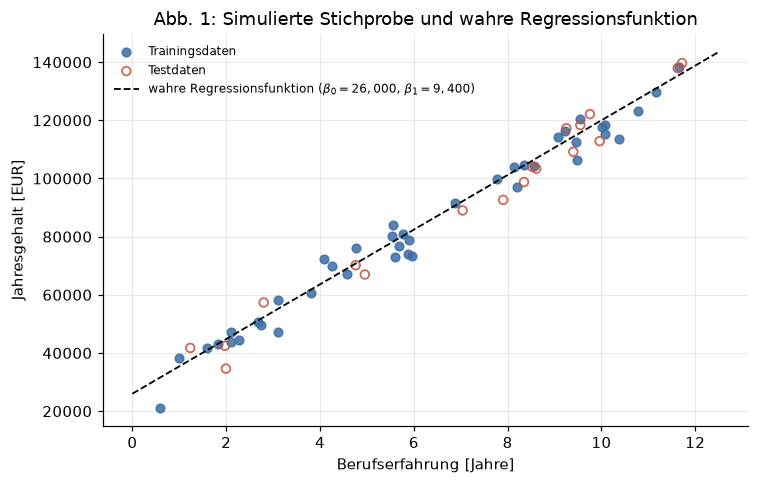

In [4]:
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, s=32, alpha=0.85, label="Trainingsdaten", color="#3b6ea5")
ax.scatter(
    X_test, y_test, s=32, alpha=0.85, label="Testdaten",
    facecolors="none", edgecolors="#c1523d", linewidths=1.2,
)
grid = np.linspace(0.0, 12.5, 100)
ax.plot(
    grid, BETA_0_TRUE + BETA_1_TRUE * grid, "k--", lw=1.2,
    label=rf"wahre Regressionsfunktion ($\beta_0={BETA_0_TRUE:,.0f}$, $\beta_1={BETA_1_TRUE:,.0f}$)",
)
ax.set_xlabel("Berufserfahrung [Jahre]")
ax.set_ylabel("Jahresgehalt [EUR]")
ax.set_title("Abb. 1: Simulierte Stichprobe und wahre Regressionsfunktion")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5 Implementierung

### 5.1 Kleinste-Quadrate-Schätzung in geschlossener Form

Die Klasse `LeastSquaresRegression` folgt der `fit`/`predict`-Konvention von
`scikit-learn`, verwendet intern aber ausschließlich `NumPy`. Das Ausgleichsproblem
wird gemäß Abschnitt 2.3 über `numpy.linalg.lstsq` (QR- bzw. SVD-basiert) gelöst und
nicht durch Inversion von $X^\top X$.

In [5]:
class LeastSquaresRegression:
    """Lineare Regression mittels Kleinste-Quadrate-Schätzung.

    Das Ausgleichsproblem :math:`\min_\beta \lVert y - X\beta\rVert_2^2` wird über eine
    QR-/SVD-basierte Zerlegung gelöst (:func:`numpy.linalg.lstsq`). Zusätzlich werden
    Standardfehler, t-Statistiken und Konfidenzintervalle der Koeffizienten bereitgestellt.

    Parameters
    ----------
    fit_intercept : bool, default=True
        Ob eine konstante Spalte in die Designmatrix aufgenommen wird.

    Attributes
    ----------
    intercept_ : float
        Geschätzter Achsenabschnitt :math:`\hat\beta_0`.
    coef_ : ndarray of shape (p,)
        Geschätzte Steigungskoeffizienten :math:`\hat\beta_1,\dots,\hat\beta_p`.
    sigma2_ : float
        Erwartungstreuer Schätzer der Störvarianz, RSS/(n - p - 1).
    rank_ : int
        Numerischer Rang der Designmatrix.
    """

    def __init__(self, fit_intercept: bool = True) -> None:
        self.fit_intercept = fit_intercept
        self.intercept_: float = 0.0
        self.coef_: np.ndarray | None = None
        self.sigma2_: float | None = None
        self.rank_: int | None = None
        self._beta: np.ndarray | None = None
        self._xtx_inv: np.ndarray | None = None
        self._n: int | None = None

    def _design_matrix(self, X: np.ndarray) -> np.ndarray:
        """Ergänzt die Merkmalsmatrix um die konstante Spalte."""
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        if not self.fit_intercept:
            return X
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LeastSquaresRegression":
        """Schätzt die Koeffizienten aus den Trainingsdaten."""
        X_design = self._design_matrix(X)
        y = np.asarray(y, dtype=np.float64).ravel()
        n, k = X_design.shape
        if n <= k:
            raise ValueError(
                f"Freiheitsgrade erschöpft: n={n} Beobachtungen bei k={k} Parametern."
            )

        beta, _, rank, _ = np.linalg.lstsq(X_design, y, rcond=None)
        if rank < k:
            raise np.linalg.LinAlgError(
                f"Designmatrix hat Rang {rank} < {k}; Annahme (A4) ist verletzt."
            )

        residuals = y - X_design @ beta
        self._beta = beta
        self._n = n
        self.rank_ = rank
        self.sigma2_ = float(residuals @ residuals) / (n - k)
        # (X'X)^-1 nur fuer die Inferenz, nicht fuer die Punktschaetzung.
        self._xtx_inv = np.linalg.pinv(X_design.T @ X_design)

        if self.fit_intercept:
            self.intercept_, self.coef_ = float(beta[0]), beta[1:]
        else:
            self.intercept_, self.coef_ = 0.0, beta
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Berechnet Vorhersagen :math:`\hat y = X\hat\beta`."""
        if self._beta is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        return self._design_matrix(X) @ self._beta

    def standard_errors(self) -> np.ndarray:
        """Standardfehler der Koeffizienten in der Reihenfolge von ``_beta``."""
        if self._beta is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        return np.sqrt(self.sigma2_ * np.diag(self._xtx_inv))

    def summary(self, feature_names: list[str] | None = None, alpha: float = 0.05) -> pd.DataFrame:
        """Koeffiziententabelle mit Standardfehlern, t-Werten und Konfidenzintervallen."""
        if self._beta is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        n_coef = len(self._beta)
        if feature_names is None:
            offset = 1 if self.fit_intercept else 0
            feature_names = [f"x{j + 1}" for j in range(n_coef - offset)]
        labels = (["const"] if self.fit_intercept else []) + list(feature_names)

        se = self.standard_errors()
        df = self._n - n_coef
        t_stat = self._beta / se
        p_value = 2.0 * stats.t.sf(np.abs(t_stat), df=df)
        t_crit = stats.t.ppf(1.0 - alpha / 2.0, df=df)

        return pd.DataFrame(
            {
                "Schätzung": self._beta,
                "Std.-Fehler": se,
                "t-Wert": t_stat,
                "p-Wert": p_value,
                f"KI {1 - alpha:.0%} unten": self._beta - t_crit * se,
                f"KI {1 - alpha:.0%} oben": self._beta + t_crit * se,
            },
            index=labels,
        )

### 5.2 Gradientenverfahren

Die iterative Variante dient dem Vergleich (Abschnitt 6.3). Die Merkmale werden intern
mit den Momenten der Trainingsdaten standardisiert; die Koeffizienten werden nach der
Optimierung analytisch auf die ursprüngliche Skala zurücktransformiert. Für
$z_j = (x_j - \mu_j)/s_j$ und $\hat y = b + \sum_j c_j z_j$ folgt

$$
\hat\beta_j = \frac{c_j}{s_j}, \qquad
\hat\beta_0 = b - \sum_j \frac{c_j \mu_j}{s_j}.
$$

In [6]:
@dataclass
class GradientDescentRegression:
    """Lineare Regression über Gradientenabstieg auf dem MSE-Kriterium.

    Parameters
    ----------
    learning_rate : float, default=0.1
        Schrittweite eta auf den standardisierten Merkmalen.
    n_iter : int, default=2000
        Maximale Anzahl an Iterationen.
    tol : float, default=1e-10
        Abbruchschwelle für die relative Abnahme des MSE.

    Attributes
    ----------
    loss_history_ : list of float
        MSE nach jeder Iteration; Grundlage der Konvergenzanalyse.
    n_iter_ : int
        Tatsächlich ausgeführte Iterationen.
    """

    learning_rate: float = 0.1
    n_iter: int = 2000
    tol: float = 1e-10
    intercept_: float = field(default=0.0, init=False)
    coef_: np.ndarray | None = field(default=None, init=False)
    loss_history_: list[float] = field(default_factory=list, init=False)
    n_iter_: int = field(default=0, init=False)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GradientDescentRegression":
        """Optimiert die Koeffizienten auf standardisierten Merkmalen."""
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        y = np.asarray(y, dtype=np.float64).ravel()
        n, p = X.shape

        mu, sd = X.mean(axis=0), X.std(axis=0)
        sd = np.where(sd == 0.0, 1.0, sd)  # konstante Merkmale nicht skalieren
        Z = (X - mu) / sd
        y_mu, y_sd = y.mean(), y.std()
        y_scaled = (y - y_mu) / y_sd

        c = np.zeros(p)
        b = 0.0
        self.loss_history_ = []
        previous_loss = np.inf

        for iteration in range(1, self.n_iter + 1):
            residual = Z @ c + b - y_scaled
            grad_c = (2.0 / n) * Z.T @ residual
            grad_b = (2.0 / n) * residual.sum()
            c -= self.learning_rate * grad_c
            b -= self.learning_rate * grad_b

            loss = float(np.mean((Z @ c + b - y_scaled) ** 2))
            self.loss_history_.append(loss)
            if abs(previous_loss - loss) < self.tol * max(1.0, abs(previous_loss)):
                self.n_iter_ = iteration
                break
            previous_loss = loss
        else:
            self.n_iter_ = self.n_iter

        # Rücktransformation auf die Originalskala.
        self.coef_ = (c * y_sd) / sd
        self.intercept_ = float(b * y_sd + y_mu - np.sum(self.coef_ * mu))
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Berechnet Vorhersagen auf der Originalskala."""
        if self.coef_ is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        return X @ self.coef_ + self.intercept_

### 5.3 Gütemaße

Die Kennzahlen werden bewusst selbst implementiert, um die Definitionen explizit zu
halten; Abschnitt 6.5 validiert sie gegen `sklearn.metrics`.

$$
\operatorname{MSE} = \frac{1}{n}\sum_i (y_i-\hat y_i)^2, \qquad
\operatorname{RMSE} = \sqrt{\operatorname{MSE}}, \qquad
\operatorname{MAE} = \frac{1}{n}\sum_i |y_i-\hat y_i|,
$$

$$
R^2 = 1 - \frac{\operatorname{RSS}}{\operatorname{TSS}}
    = 1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2},
\qquad
R^2_{\text{adj}} = 1 - (1-R^2)\,\frac{n-1}{n-p-1}.
$$

In [7]:
def regression_metrics(
    y_true: np.ndarray, y_pred: np.ndarray, n_features: int = 1
) -> dict[str, float]:
    """Berechnet MSE, RMSE, MAE, R² und adjustiertes R².

    Parameters
    ----------
    y_true, y_pred : ndarray of shape (n,)
        Beobachtete und vorhergesagte Werte.
    n_features : int, default=1
        Anzahl der Merkmale p; benötigt für das adjustierte R².

    Returns
    -------
    dict of str to float
    """
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    n = y_true.size
    residual = y_true - y_pred
    rss = float(residual @ residual)
    tss = float(((y_true - y_true.mean()) ** 2).sum())
    r2 = 1.0 - rss / tss
    adjusted = (
        1.0 - (1.0 - r2) * (n - 1) / (n - n_features - 1)
        if n - n_features - 1 > 0
        else np.nan
    )
    return {
        "MSE": rss / n,
        "RMSE": float(np.sqrt(rss / n)),
        "MAE": float(np.abs(residual).mean()),
        "R2": r2,
        "R2_adj": adjusted,
    }

<a id="6"></a>
## 6 Empirische Analyse

### 6.1 Punktschätzung und Inferenz

In [8]:
ols = LeastSquaresRegression().fit(X_train, y_train)

print("Kleinste-Quadrate-Schätzung (Trainingsmenge)")
print(f"  beta_0_hat = {ols.intercept_:11,.2f} EUR      (wahr: {BETA_0_TRUE:,.2f})")
print(f"  beta_1_hat = {ols.coef_[0]:11,.2f} EUR/Jahr (wahr: {BETA_1_TRUE:,.2f})")
print(f"  sigma_hat  = {np.sqrt(ols.sigma2_):11,.2f} EUR      (wahr: {SIGMA_TRUE:,.2f})")

summary_table = ols.summary(feature_names=["berufserfahrung_jahre"])
display(summary_table)

Kleinste-Quadrate-Schätzung (Trainingsmenge)
  beta_0_hat =   25,554.81 EUR      (wahr: 26,000.00)
  beta_1_hat =    9,284.19 EUR/Jahr (wahr: 9,400.00)
  sigma_hat  =    4,478.79 EUR      (wahr: 6,000.00)


,Schätzung,Std.-Fehler,t-Wert,p-Wert,KI 95% unten,KI 95% oben
const,25554.8084,1515.8065,16.8589,8.9062e-20,22491.2492,28618.3675
berufserfahrung_jahre,9284.1907,218.5501,42.4808,6.6955e-35,8842.4844,9725.8970


**Interpretation.** Die Punktschätzungen liegen erwartungsgemäß in der Nähe der wahren
Parameter, ohne mit ihnen zusammenzufallen: bei $n=42$ Trainingsbeobachtungen ist die
Stichprobenstreuung des Schätzers nicht zu vernachlässigen. Entscheidend ist, dass die
wahren Werte innerhalb der jeweiligen 95-%-Konfidenzintervalle liegen — das erwartet man
unter korrekt spezifiziertem Modell in etwa 95 % aller Stichprobenziehungen. Der sehr
kleine $p$-Wert der Steigung verwirft die Nullhypothese $\beta_1 = 0$ deutlich, was bei
einem konstruierten Zusammenhang dieser Stärke nicht überrascht. Der Achsenabschnitt ist
hier inhaltlich interpretierbar (erwartetes Gehalt bei null Berufsjahren), weil
$x = 0$ am Rand des beobachteten Wertebereichs liegt; bei Merkmalen ohne sinnvollen
Nullpunkt ist eine solche Interpretation unzulässig.

### 6.2 Generalisierungsleistung

In [9]:
metrics = pd.DataFrame(
    {
        "Trainingsmenge": regression_metrics(y_train, ols.predict(X_train)),
        "Testmenge": regression_metrics(y_test, ols.predict(X_test)),
    }
)
display(metrics)

print(f"Theoretische Untergrenze des RMSE (sigma des DGP): {SIGMA_TRUE:,.2f} EUR")

,Trainingsmenge,Testmenge
MSE,1.9104e+07,2.2810e+07
RMSE,4.3709e+03,4.7760e+03
MAE,3.5009e+03,4.2327e+03
R2,9.7832e-01,9.7752e-01
R2_adj,9.7777e-01,9.7611e-01


Theoretische Untergrenze des RMSE (sigma des DGP): 6,000.00 EUR


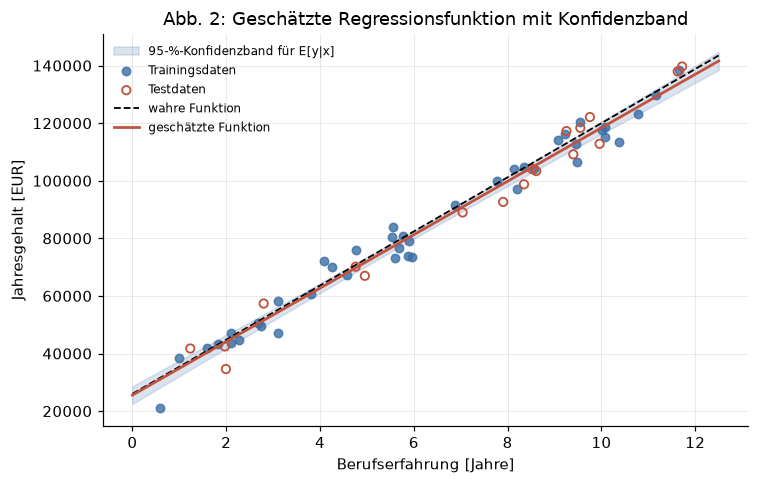

In [10]:
grid = np.linspace(0.0, 12.5, 200).reshape(-1, 1)

# Konfidenzband fuer den Erwartungswert der Zielgroesse (siehe Abschnitt 2.6).
X_grid_design = np.hstack([np.ones_like(grid), grid])
leverage = np.einsum("ij,jk,ik->i", X_grid_design, ols._xtx_inv, X_grid_design)
se_mean = np.sqrt(ols.sigma2_ * leverage)
t_crit = stats.t.ppf(0.975, df=len(X_train) - 2)
y_grid = ols.predict(grid)

fig, ax = plt.subplots()
ax.fill_between(
    grid.ravel(), y_grid - t_crit * se_mean, y_grid + t_crit * se_mean,
    color="#3b6ea5", alpha=0.18, label="95-%-Konfidenzband für E[y|x]",
)
ax.scatter(X_train, y_train, s=30, alpha=0.8, color="#3b6ea5", label="Trainingsdaten")
ax.scatter(
    X_test, y_test, s=30, facecolors="none", edgecolors="#c1523d",
    linewidths=1.2, label="Testdaten",
)
ax.plot(grid, BETA_0_TRUE + BETA_1_TRUE * grid.ravel(), "k--", lw=1.2, label="wahre Funktion")
ax.plot(grid, y_grid, color="#c1523d", lw=1.8, label="geschätzte Funktion")
ax.set_xlabel("Berufserfahrung [Jahre]")
ax.set_ylabel("Jahresgehalt [EUR]")
ax.set_title("Abb. 2: Geschätzte Regressionsfunktion mit Konfidenzband")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 6.3 Konvergenz des Gradientenverfahrens

Verglichen werden drei Lernraten. Erwartet wird, dass alle Läufe gegen dieselbe
geschlossene Lösung konvergieren, sich aber deutlich in der benötigten Iterationszahl
unterscheiden.

In [11]:
learning_rates = [0.005, 0.05, 0.30]
gd_models: dict[float, GradientDescentRegression] = {}
rows = []

for eta in learning_rates:
    gd = GradientDescentRegression(learning_rate=eta, n_iter=4000).fit(X_train, y_train)
    gd_models[eta] = gd
    rows.append(
        {
            "Lernrate": eta,
            "Iterationen": gd.n_iter_,
            "beta_0_hat": gd.intercept_,
            "beta_1_hat": gd.coef_[0],
            "Abweichung zu OLS [EUR]": abs(gd.coef_[0] - ols.coef_[0]),
            "Test-RMSE": regression_metrics(y_test, gd.predict(X_test))["RMSE"],
        }
    )

comparison = pd.DataFrame(rows).set_index("Lernrate")
display(comparison)
print(f"Referenz (geschlossene Lösung): beta_0_hat = {ols.intercept_:,.2f}, "
      f"beta_1_hat = {ols.coef_[0]:,.2f}")

,Iterationen,beta_0_hat,beta_1_hat,Abweichung zu OLS [EUR],Test-RMSE
Lernrate,,,,,
0.005,951,25558.8570,9283.5348,0.6559,4776.4159
0.050,103,25555.9181,9284.0109,0.1798,4776.1121
0.300,14,25554.9622,9284.1658,0.0249,4776.0135


Referenz (geschlossene Lösung): beta_0_hat = 25,554.81, beta_1_hat = 9,284.19


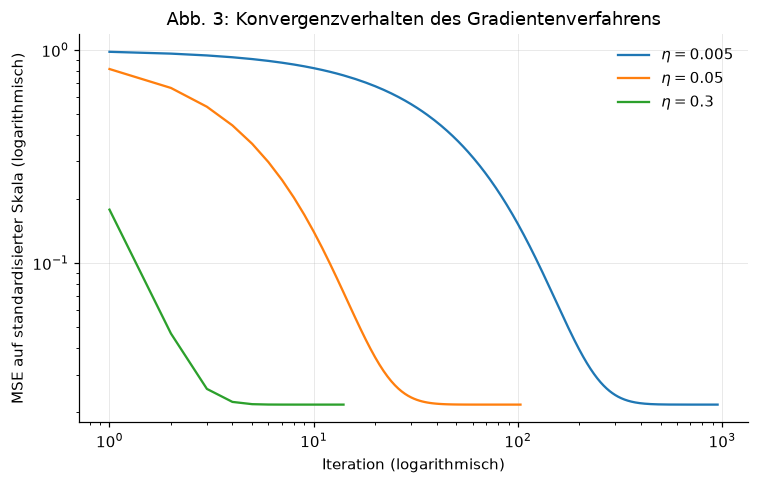

In [12]:
fig, ax = plt.subplots()
for eta, gd in gd_models.items():
    ax.plot(np.arange(1, gd.n_iter_ + 1), gd.loss_history_, lw=1.5, label=rf"$\eta = {eta}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iteration (logarithmisch)")
ax.set_ylabel("MSE auf standardisierter Skala (logarithmisch)")
ax.set_title("Abb. 3: Konvergenzverhalten des Gradientenverfahrens")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Die Verlustkurven fallen monoton — ein Indiz dafür, dass alle drei
Lernraten im stabilen Bereich $\eta < 1/\lambda_{\max}$ liegen. Die kleinste Lernrate
benötigt rund zwei Größenordnungen mehr Iterationen für dasselbe Ergebnis, während die
größte nach wenigen Hundert Schritten austerminiert. Da das Problem konvex ist, ist die
Wahl von $\eta$ keine Frage der Lösungs*qualität*, sondern ausschließlich des
Rechenaufwands. Bei $\eta$ oberhalb der Stabilitätsgrenze würde die Kurve divergieren
(siehe Übungsaufgabe 3).

### 6.4 Residuendiagnostik

Die Modellannahmen (A1)–(A3) werden grafisch geprüft: Residuen gegen angepasste Werte
(Linearität, Homoskedastizität) und Normal-Quantil-Diagramm (A5).

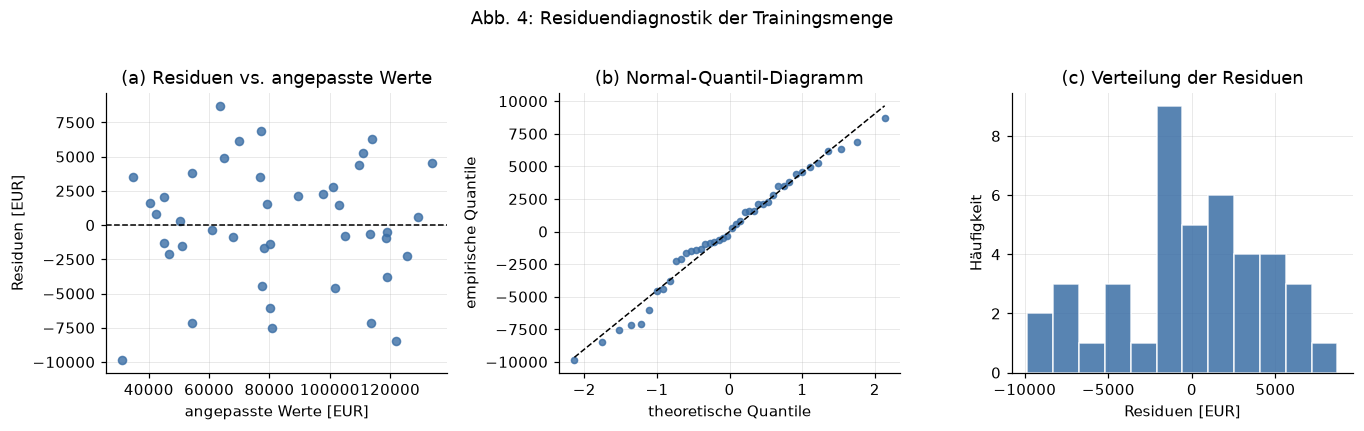

Shapiro-Wilk-Test auf Normalität: W = 0.9787, p = 0.6100
Mittelwert der Residuen: 6.41e-12 EUR (konstruktionsbedingt näherungsweise null)


In [13]:
residuals_train = y_train - ols.predict(X_train)
fitted_train = ols.predict(X_train)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

axes[0].scatter(fitted_train, residuals_train, s=28, alpha=0.8, color="#3b6ea5")
axes[0].axhline(0.0, color="black", lw=1.0, ls="--")
axes[0].set_xlabel("angepasste Werte [EUR]")
axes[0].set_ylabel("Residuen [EUR]")
axes[0].set_title("(a) Residuen vs. angepasste Werte")

stats.probplot(residuals_train, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(marker="o", markersize=4, alpha=0.8, color="#3b6ea5")
axes[1].get_lines()[1].set(color="black", lw=1.0, ls="--")
axes[1].set_title("(b) Normal-Quantil-Diagramm")
axes[1].set_xlabel("theoretische Quantile")
axes[1].set_ylabel("empirische Quantile")

axes[2].hist(residuals_train, bins=12, color="#3b6ea5", alpha=0.85, edgecolor="white")
axes[2].set_xlabel("Residuen [EUR]")
axes[2].set_ylabel("Häufigkeit")
axes[2].set_title("(c) Verteilung der Residuen")

fig.suptitle("Abb. 4: Residuendiagnostik der Trainingsmenge", y=1.02)
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_train)
print(f"Shapiro-Wilk-Test auf Normalität: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
print(f"Mittelwert der Residuen: {residuals_train.mean():,.2e} EUR "
      "(konstruktionsbedingt näherungsweise null)")

**Interpretation.** Die Residuen streuen ohne erkennbares Muster um die Nulllinie, die
Punkte im Q-Q-Diagramm folgen im Wesentlichen der Referenzgeraden, und der
Shapiro-Wilk-Test verwirft die Normalitätshypothese nicht ($p > 0.05$). Das ist hier
keine Bestätigung des Modells, sondern eine **Kontrolle der Methode**: Da der DGP aus
Abschnitt 4 die Annahmen exakt erfüllt, *müssen* diese Diagramme unauffällig sein.
Ein systematisches Muster in (a) wäre folglich ein Hinweis auf einen Implementierungs-
oder Auswertungsfehler. Der praktische Nutzen der Diagnostik zeigt sich erst bei
fehlspezifizierten Modellen — Übungsaufgabe 2 stellt einen solchen Fall her.

### 6.5 Validierung gegen `scikit-learn`

Abschließend werden Koeffizienten und Kennzahlen mit der Referenzimplementierung
verglichen. Zusätzlich wird der numerische Vorteil der QR-basierten Lösung gegenüber
der expliziten Inversion der Normalengleichungen an einer schlecht konditionierten
Designmatrix demonstriert.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reference = LinearRegression().fit(X_train, y_train)
own_metrics = regression_metrics(y_test, ols.predict(X_test))

validation = pd.DataFrame(
    {
        "Eigenimplementierung": [
            ols.intercept_,
            ols.coef_[0],
            own_metrics["MSE"],
            own_metrics["MAE"],
            own_metrics["R2"],
        ],
        "scikit-learn": [
            reference.intercept_,
            reference.coef_[0],
            mean_squared_error(y_test, reference.predict(X_test)),
            mean_absolute_error(y_test, reference.predict(X_test)),
            r2_score(y_test, reference.predict(X_test)),
        ],
    },
    index=["beta_0_hat", "beta_1_hat", "MSE (Test)", "MAE (Test)", "R2 (Test)"],
)
validation["absolute Differenz"] = (
    validation["Eigenimplementierung"] - validation["scikit-learn"]
).abs()
display(validation)

assert np.allclose(ols.intercept_, reference.intercept_, rtol=1e-8)
assert np.allclose(ols.coef_, reference.coef_, rtol=1e-8)
print("Übereinstimmung mit scikit-learn bis auf Maschinengenauigkeit bestätigt.")

,Eigenimplementierung,scikit-learn,absolute Differenz
beta_0_hat,2.5555e+04,2.5555e+04,5.4570e-11
beta_1_hat,9.2842e+03,9.2842e+03,5.4570e-12
MSE (Test),2.2810e+07,2.2810e+07,5.5879e-08
MAE (Test),4.2327e+03,4.2327e+03,6.3665e-12
R2 (Test),9.7752e-01,9.7752e-01,1.1102e-16


Übereinstimmung mit scikit-learn bis auf Maschinengenauigkeit bestätigt.


In [15]:
# Numerische Stabilitaet: Vandermonde-Matrix als bewusst schlecht konditionierter Fall.
generator = np.random.default_rng(RANDOM_STATE)
x_ill = np.linspace(1.0, 2.0, 40)
X_ill = np.vander(x_ill, N=9, increasing=True)[:, 1:]  # x^1 ... x^8
beta_ill = np.arange(1.0, 10.0)
y_ill = beta_ill[0] + X_ill @ beta_ill[1:] + generator.normal(0.0, 1e-6, size=x_ill.size)

X_design_ill = np.hstack([np.ones((X_ill.shape[0], 1)), X_ill])
beta_qr, *_ = np.linalg.lstsq(X_design_ill, y_ill, rcond=None)
beta_inv = np.linalg.inv(X_design_ill.T @ X_design_ill) @ X_design_ill.T @ y_ill

print(f"Konditionszahl kappa(X)     = {np.linalg.cond(X_design_ill):.3e}")
print(f"Konditionszahl kappa(X'X)   = {np.linalg.cond(X_design_ill.T @ X_design_ill):.3e}")
print(f"max. Fehler QR/lstsq        = {np.abs(beta_qr - beta_ill).max():.3e}")
print(f"max. Fehler explizite Inv.  = {np.abs(beta_inv - beta_ill).max():.3e}")

Konditionszahl kappa(X)     = 3.171e+09
Konditionszahl kappa(X'X)   = 1.077e+18
max. Fehler QR/lstsq        = 1.570e+00
max. Fehler explizite Inv.  = 5.691e+03


**Interpretation.** Bei $\kappa(X^\top X) \approx \kappa(X)^2$ verliert die explizite
Inversion rund die Hälfte der verfügbaren Stellen. Der Fehler in den Koeffizienten ist
um mehrere Größenordnungen größer als bei der QR-basierten Lösung, obwohl beide
Verfahren dieselbe mathematische Größe berechnen. Für gut konditionierte Probleme wie
das Gehaltsbeispiel ist der Unterschied irrelevant; polynomiale oder stark korrelierte
Merkmale führen jedoch schnell in diesen Bereich. Die Lehre daraus: Zwischen der Formel
$\hat\beta = (X^\top X)^{-1}X^\top y$ und ihrer Implementierung liegt eine methodische
Entscheidung.

<a id="7"></a>
## 7 Diskussion und Grenzen

**Ergebnis.** Die Eigenimplementierung reproduziert `scikit-learn` bis auf
Maschinengenauigkeit; die wahren Parameter des DGP liegen innerhalb der geschätzten
Konfidenzintervalle, und der Test-RMSE liegt in der Größenordnung von $\sigma$ — mehr
ist unter diesem DGP prinzipiell nicht erreichbar, da $\sigma$ die irreduzible
Fehlerkomponente darstellt.

**Methodische Einschränkungen.**

1. *Simulierter DGP.* Alle Annahmen sind konstruktionsgemäß erfüllt. Reale Daten
   verletzen typischerweise (A1) und (A3); die hier gezeigte Diagnostik ist dort
   ungleich informativer.
2. *Einzelne Aufteilung.* Kennzahlen aus einem einzigen Train/Test-Split unterliegen
   bei $n=60$ erheblicher Streuung. Belastbare Aussagen erfordern Kreuzvalidierung
   oder wiederholte Aufteilungen (siehe Notebook 03).
3. *Keine Regularisierung.* Bei $p \gg n$ oder kollinearen Merkmalen ist die
   Kleinste-Quadrate-Lösung nicht mehr eindeutig bzw. hochvariabel. Ridge- und
   Lasso-Regression adressieren dies durch $\ell_2$- bzw. $\ell_1$-Strafterme
   (Hastie et al., 2009, Kap. 3.4).
4. *Kausalität.* Alle Aussagen sind assoziativ. Der geschätzte Koeffizient
   $\hat\beta_1$ ist auch im simulierten Fall nur deshalb kausal interpretierbar, weil
   der DGP bekannt ist — nicht weil die Regression dies leisten könnte.

**Anschluss.** Notebook 02 überträgt das Vorgehen auf binäre Zielgrößen und ersetzt das
Kleinste-Quadrate- durch das Maximum-Likelihood-Kriterium.

<a id="8"></a>
## 8 Übungsaufgaben

1. **Stichprobenverteilung des Schätzers.** Simulieren Sie $M = 1000$ unabhängige
   Stichproben aus dem DGP von Abschnitt 4 und schätzen Sie jeweils $\hat\beta_1$.
   Vergleichen Sie Mittelwert und Standardabweichung der resultierenden Verteilung mit
   $\beta_1$ und dem theoretischen Standardfehler aus Abschnitt 2.6. Prüfen Sie
   empirisch die Überdeckungsrate des 95-%-Konfidenzintervalls.
2. **Fehlspezifikation.** Ersetzen Sie den DGP durch
   $y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \varepsilon_i$ mit $\beta_2 = 400$ und
   passen Sie weiterhin das lineare Modell an. Welches Muster zeigt Abb. 4 (a)?
   Erweitern Sie anschließend die Designmatrix um $x^2$.
3. **Stabilitätsgrenze.** Bestimmen Sie $\lambda_{\max}$ von $\frac{1}{n}Z^\top Z$ für
   die standardisierte Designmatrix und damit die theoretische Obergrenze für $\eta$.
   Verifizieren Sie die Divergenz für $\eta > 2/\lambda_{\max}$.
4. **Heteroskedastizität.** Erzeugen Sie Störterme mit $\sigma_i = \sigma \cdot x_i$.
   Bleibt $\hat\beta$ erwartungstreu? Was geschieht mit den Standardfehlern und der
   Überdeckungsrate der Konfidenzintervalle?
5. **Multiple Regression.** Erweitern Sie den DGP um ein zweites Merkmal, das mit dem
   ersten zu $\rho = 0.95$ korreliert. Beobachten Sie Standardfehler und
   Konditionszahl und erklären Sie das Phänomen der Multikollinearität.

<a id="9"></a>
## 9 Literatur

* Golub, G. H., & Van Loan, C. F. (2013). *Matrix Computations* (4. Aufl.).
  Johns Hopkins University Press.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning: Data Mining, Inference, and Prediction* (2. Aufl.). Springer. Kap. 3.
* James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to
  Statistical Learning* (2. Aufl.). Springer. Kap. 3.
* Wooldridge, J. M. (2020). *Introductory Econometrics: A Modern Approach* (7. Aufl.).
  Cengage. Kap. 2–4.